In [1]:
import h5py
import torch

with h5py.File("quark-gluon_data-set_n139306.hdf5", "r") as f:
    print(list(f.keys()))

with h5py.File("quark-gluon_data-set_n139306.hdf5", "r") as f:
    X = f["X_jets"][:]
    y = f["y"][:]

['X_jets', 'm0', 'pt', 'y']


In [2]:
# No início, ao processar X:
X = torch.log1p(torch.tensor(X, dtype=torch.float32))
X = X.permute(0, 3, 1, 2).contiguous()

In [3]:
# Após converter para tensor e fazer o permute:
for c in range(3):
    channel_max = X[:, c, :, :].max()
    if channel_max > 0:
        X[:, c, :, :] /= channel_max

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [5]:
print(X_train.min(), X_train.max())

tensor(0.) tensor(1.)


In [6]:
X_train = torch.as_tensor(X_train, dtype=torch.float32)
X_val = torch.as_tensor(X_val, dtype=torch.float32)
X_test = torch.as_tensor(X_test, dtype=torch.float32)

y_train = torch.as_tensor(y_train, dtype=torch.long)
y_val = torch.as_tensor(y_val, dtype=torch.long)
y_test = torch.as_tensor(y_test, dtype=torch.long)

In [7]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [8]:
import torch.nn as nn

class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),  # 125 -> 63
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 63 -> 32
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 32 -> 16
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),  
        )

    # Identação correta: alinhado com o __init__
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        # O .contiguous() resolve o RuntimeError anterior
        return x_hat[:, :, :125, :125].contiguous()

# IMPORTANTE: Re-instanciar o modelo para aplicar as mudanças!
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ConvAutoEncoder().to(device)

# Recriar o otimizador para linkar com os novos parâmetros do modelo
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [9]:
criterion = torch.nn.SmoothL1Loss()

In [10]:
print(X_train.shape)

torch.Size([97514, 3, 125, 125])


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64, # Reduzi de 128 para 64 para aliviar a memória
    shuffle=True,
    num_workers=0,  # OBRIGATÓRIO: 0 evita o crash de multiprocessamento no Mac
    pin_memory=False # No MPS, pin_memory às vezes causa instabilidade
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [12]:
epochs = 8

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for X_batch, _ in train_loader:

        X_batch = X_batch.to(device)

        optimizer.zero_grad()

        output = model(X_batch)

        loss = criterion(output, X_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.detach().cpu().item()

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for X_batch, _ in val_loader:
            X_batch = X_batch.to(device)
            
            output = model(X_batch)

            loss = criterion(output, X_batch)

            val_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"loss={train_loss/len(train_loader):.12f} | "
        f"val_loss={val_loss/len(val_loader):.12f}"
    )

Epoch 1/8 | loss=0.000097554047 | val_loss=0.000000406264
Epoch 2/8 | loss=0.000000463749 | val_loss=0.000000392758
Epoch 3/8 | loss=0.000000440126 | val_loss=0.000000339928
Epoch 4/8 | loss=0.000000342632 | val_loss=0.000001185306
Epoch 5/8 | loss=0.000000262705 | val_loss=0.000000186927
Epoch 6/8 | loss=0.000000228310 | val_loss=0.000000182215
Epoch 7/8 | loss=0.000000212582 | val_loss=0.000000157742
Epoch 8/8 | loss=0.000000188709 | val_loss=0.000000194293


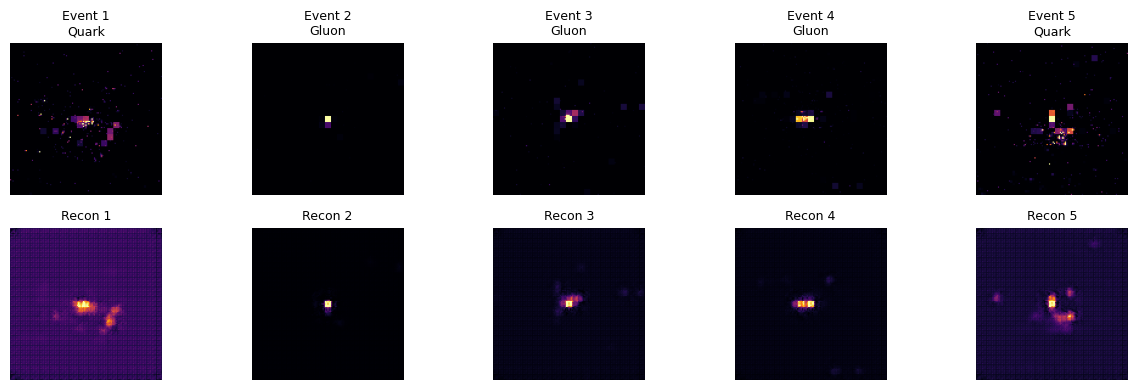

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_image(image):
    image = image.sum(0).cpu().numpy()
    
    vmax = np.percentile(image, 99.9) if np.max(image) > 0 else 1.0
    
    plt.imshow(image, cmap="inferno", vmin=1e-5, vmax=vmax)
    plt.axis("off")


def show_reconstructions(model, dataloader, n_images=5):
    model.eval()

    with torch.no_grad():
        X, y = next(iter(dataloader))
        X = X[:n_images]
        y = y[:n_images]

        reconstructions = model(X.to('mps')).cpu()

        fig = plt.figure(figsize=(n_images * 2.5, 4))

        for i in range(n_images):

            label = "Quark" if y[i].item() == 0 else "Gluon"

            # Original
            plt.subplot(2, n_images, 1 + i)
            plot_image(X[i])
            plt.title(f"Event {i+1}\n{label}", fontsize=9)

            # Reconstruction
            plt.subplot(2, n_images, 1 + n_images + i)
            plot_image(reconstructions[i])
            plt.title(f"Recon {i+1}", fontsize=9)

    plt.tight_layout()
    plt.show()


show_reconstructions(model, val_loader)